## Clasificación

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas.testing as tm
%matplotlib inline

In [2]:
url = "https://github.com/ulewis/Ejemplos/raw/main/Datos/Classified_Data.txt"
df = pd.read_csv(url,index_col=0)
# llamamos las 5 primeras filas
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


### info() *>> da información detallada*

In [3]:
df.info() # pedimos información detallada

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


## describe() *>> resumen de estadísticas*

In [4]:
df.describe() # pedimos un resumen de las estadísticas

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


In [5]:
l = list(df.columns)
print(l)

['WTT', 'PTI', 'EQW', 'SBI', 'LQE', 'QWG', 'FDJ', 'PJF', 'HQE', 'NXJ', 'TARGET CLASS']


### Boxplots

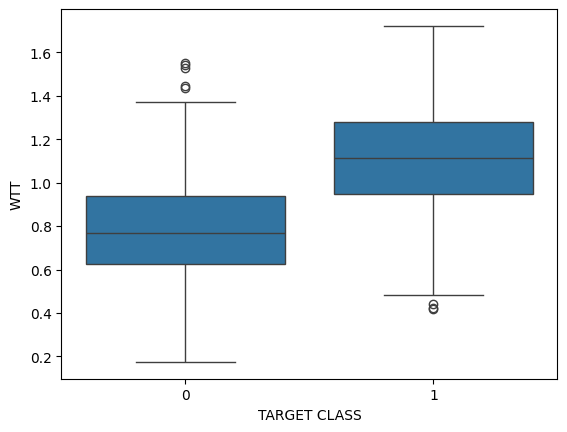

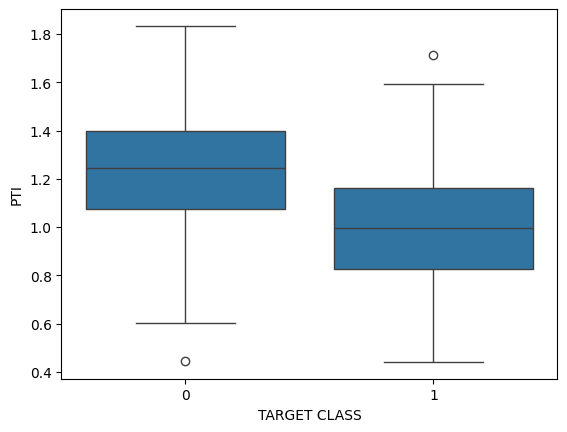

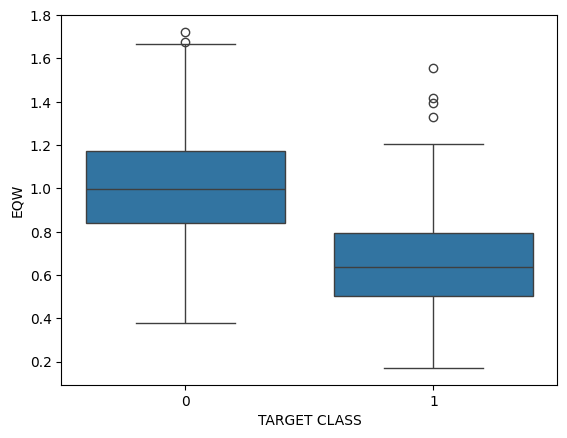

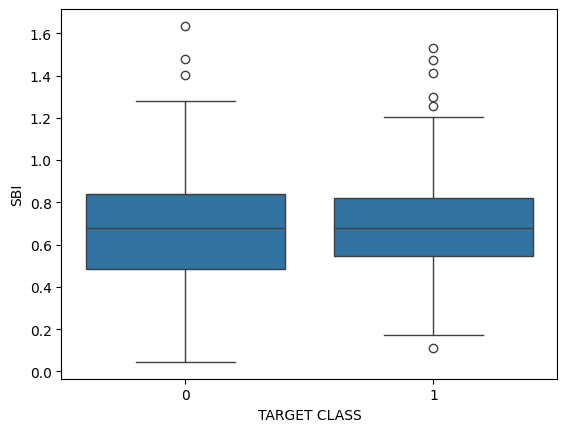

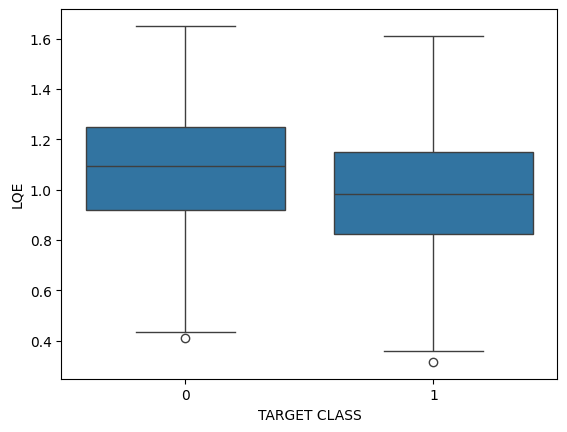

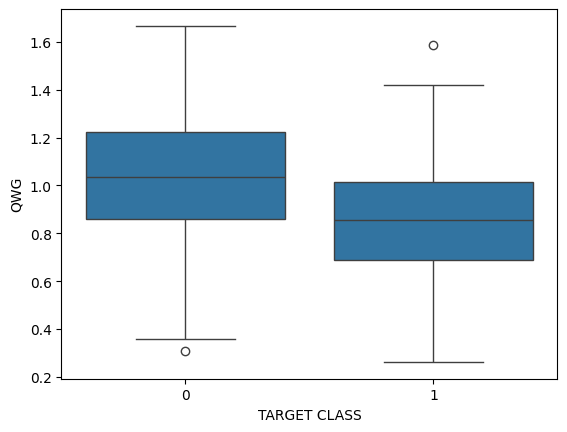

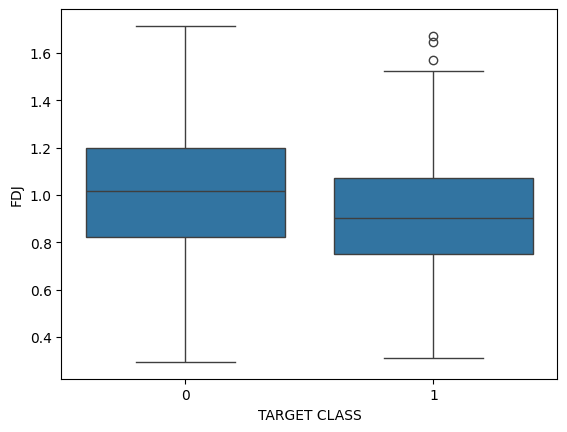

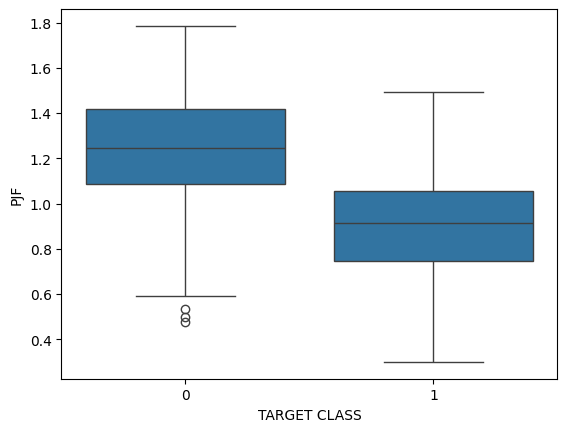

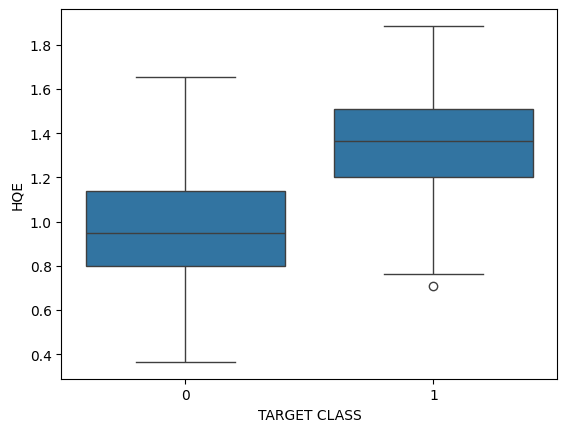

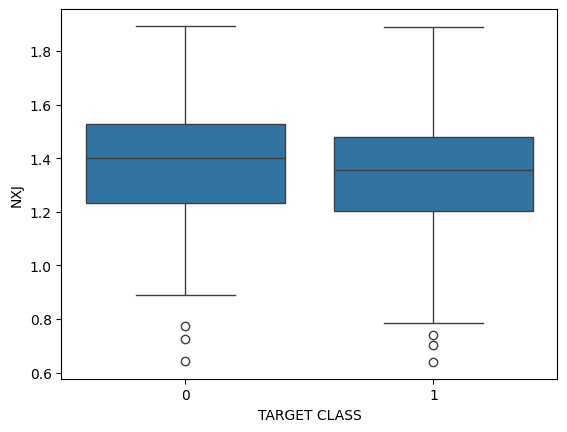

<Figure size 640x480 with 0 Axes>

In [6]:
for i in range(len(l)-1): # hasta la penúltima columna
    sns.boxplot(x='TARGET CLASS',y=l[i], data=df)
    plt.figure()

# Escalamos características

### Preprocesamiento

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

### Meta: predecir TARGET CLASS

In [ ]:
scaler.fit(df.drop('TARGET CLASS',axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))

In [ ]:
df_feat = pd.DataFrame(scaled_features,columns = df.columns[:-1]) #sin contar la penúltima columna
df_feat.head()# muestra las 5 primeras filas

#División entrenamiento-prueba
### Ajuste del modelo y predicción

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_feat  # usamos el data frame estandarizado
y = df['TARGET CLASS']  # usamos la columna de resultados

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,  # 50% para prueba y 50% para entrenamiento
    random_state=101  # semilla para la reproducibilidad
)

# 🚩 KNN
### (K-Nearest Neighbors)
* Decide a qué clase pertenece un nuevo dato observando qué clase tienen sus vecinos más cercanos.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k=11
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train,y_train)

In [ ]:
pred = knn.predict(X_test)

### Evaluación de la calidad de clasificación

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
conf_mat=confusion_matrix(y_test,pred)
print(conf_mat)

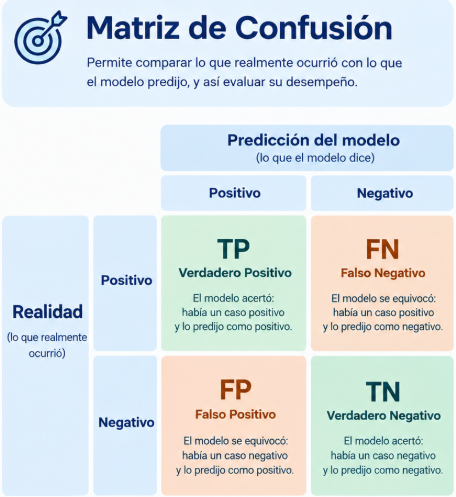

In [ ]:
import seaborn as sns

sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(y_test,pred))

In [ ]:
print("Tasa de error de clasificación errónea:",round(np.mean(pred!=y_test),3))

# Elegimos 'k' por el metodo del "*elbow*"

In [ ]:
error_rate = []

for i in range(1,60):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)  # entrenamos
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))  # ¿qué tan cierto es 'Falso'?

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,60),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Tasa de Error vs. Valor de K', fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('Tasa de Error de Clasificación errónea',fontsize=15)

* A medida que crece el K el error se reduce
* El error se mantiene casi en el mismo rango desde aproximádamente 48

El error se estabiliza entre 5 a 6%

# 🚩Naive Bayes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df1 = pd.read_csv('https://github.com/ulewis/Ejemplos/raw/main/Datos/wine.data.csv')
df1.head(10) # muestra las 10 primeras filas

### Estadística básica

In [ ]:
df1.iloc[:,1:].describe().T

### Boxplots

In [ ]:
for c in df1.columns[1:]:
    df1.boxplot(c,by='Class',figsize=(7,4),fontsize=14)
    plt.title("{}\n".format(c),fontsize=16)
    plt.xlabel("Wine Class", fontsize=16)

Se puede ver que algunas características clasifican las etiquetas de los vinos con bastante claridad
* Por ejemplo, la alcalinidad, los fenoles totales o los flavonoides producen diagramas de caja con medianas bien separadas, que son claramente indicativas de las clases de vinos.

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    df1['OD280/OD315 of diluted wines'],
    df1['Flavanoids'],
    c=df1['Class'],
    edgecolors='k',
    alpha=0.8,s=100
)
plt.grid(True)
plt.title("Scatter plot of two features showing the \ncorrelation and class seperation",fontsize=15)
plt.xlabel("OD280/OD315 of diluted wines",fontsize=15)
plt.ylabel("Flavanoids",fontsize=15)

* Si los colores están bien separados, significa que estas características pueden predecir la clase
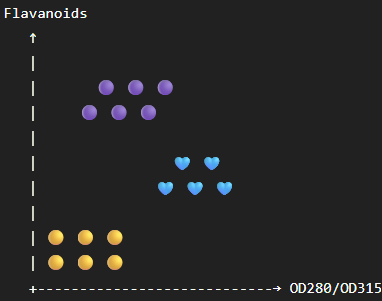
* Si estan mezclados será difícil distinguir usando esas dos variables
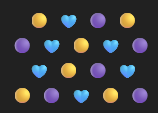

### ¿Son las funciones independientes? 🤔

In [ ]:
# Construimos una matriz de correlación para TODAS las variables del df1

In [ ]:
def correlation_matrix(df1):
    from matplotlib import pyplot as plt
    from matplotlib import cm as cm

    fig = plt.figure(figsize=(16,12))
    ax1 = fig.add_subplot(111)
    cmap = cm.get_cmap('jet', 30)
    cax = ax1.imshow(df1.corr(), interpolation="nearest", cmap=cmap)
    ax1.grid(True)
    plt.title('Wine data set features correlation\n',fontsize=15)
    labels=df1.columns
    ax1.set_xticklabels(labels,fontsize=9)
    ax1.set_yticklabels(labels,fontsize=9)
    fig.colorbar(cax, ticks=[0.1*i for i in range(-11,11)])
    plt.show()

correlation_matrix(df1)

### Clasificación Naive Bayes

In [ ]:
X1 = df1.drop('Class', axis=1) # no consideramos la clase
y1 = df1['Class']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3)

In [ ]:
X1_train.head()# muestra las 5 primeras filas de X1

* Clasificación GaussianNB: Aprende las características de cada clase y, cuando recibe un nuevo vino, calcula a qué clase es más probable que pertenezca.

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nbc = GaussianNB()

In [ ]:
nbc.fit(X1_train, y1_train)

In [ ]:
y1_pred = nbc.predict(X1_test)
mislabel = np.sum((y1_test!=y1_pred))
print("La cantidad total de puntos de datos mal etiquetados de {} muestras de prueba es {}".format(len(y1_test),mislabel))

In [ ]:
print("El informe de clasificación es el siguiente...\n")
print(classification_report(y1_pred, y1_test)) # pedimos el informe de clasificación

In [ ]:
cm = confusion_matrix(y1_test, y1_pred) # matriz de confusión
cmdf = pd.DataFrame(cm,index=['Class 1','Class 2',' Class 3'], columns=['Class 1','Class 2',' Class 3'])
print("La matriz de confusión es la siguiente...\n")
cmdf

Esto mostró que incluso en presencia de correlación entre las características, el algoritmo Naive Bayes funcionó bastante bien y podría separar las clases fácilmente

# 🚩 Kappa (Cohen) y Validación Cruzada en Clasificación

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    make_scorer,
)

In [ ]:
data = load_breast_cancer() # Carga el dataset Breast Cancer Wisconsin
X2 = pd.DataFrame(data.data, columns=data.feature_names)
y2 = pd.Series(data.target, name="target")  # 0=maligno, 1=benigno

y2.value_counts()

## Cohen's kappa (k)
Es una medida del grado de acuerdo entre dos evaluadores:
* El modelo
* La etiqueta real (ground truth)

Interpretación
* **k = 1**: acuerdo perfecto.
* **k = 0**: el acuerdo es equivalente al azar.
* **k < 0**: el acuerdo es peor que el azar.
>*En la práctica, valores mayores a 0.6 suelen considerarse indicativos de buen acuerdo, aunque esta interpretación depende del contexto del problema.*

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
) # dividimos entrenamiento-prueba

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, n_jobs=None, solver="lbfgs"))
])

pipe.fit(X2_train, y2_train) # entrenamiento
pred2 = pipe.predict(X2_test) # predicción

acc = accuracy_score(y2_test, pred2)
kappa = cohen_kappa_score(y2_test, pred2)

acc, kappa

* 0.986 = 98.60%
* 0.970 -> El acuerdo es muy alto entre las predicciones y las clases reales

kappa nos demuestra cuánto de lo acertado está bien clasificado

In [ ]:
cm2 = confusion_matrix(y2_test, pred2)  # matriz de confusión

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=data.target_names
)

disp2.plot(values_format="d")
plt.title("Matriz de confusión (hold-out)")
plt.show()

# Reporte de clasificación
print(classification_report(
    y2_test,
    pred2,
    target_names=data.target_names
))

### Cross-Validation
Validación cruzada
> Estima el rendimiento del modelo de forma más robusta que un solo split train/test.

K-fold CV:
* Se divide el conjunto de datos en K particiones (folds).
* Se entrena el modelo K veces:
  * cada vez usa K-1 folds para entrenar
  * y 1 fold distinto para validar
* Se promedian las métricas.

>> *Importante: cualquier preprocesamiento (p. ej., escalado) debe estar dentro del CV, por eso usamos Pipeline.*



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Entrenamiento   Evaluación
# Fold 2,3,4,5    Fold 1


scoring = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score)
}

results = cross_validate(
    pipe, X2, y2,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

pd.DataFrame(results).agg(["mean", "std"])

* fit_time: tiempo que tarda el computador en entrenar el modelo en cada fold
* score_time: tiempo que tarda en evaluar o puntuar el modelo

###Distribución de métricas por fold

In [ ]:
df3 = pd.DataFrame({
    "accuracy": results["test_accuracy"],
    "kappa": results["test_kappa"],
})

df3

In [ ]:
plt.figure()
plt.boxplot([df3["accuracy"], df3["kappa"]], labels=["accuracy", "kappa"])
plt.title("Métricas por fold (5-fold Stratified CV)")
plt.ylabel("Score")
plt.show()

print("Accuracy media ± std:", df3["accuracy"].mean(), "±", df3["accuracy"].std())
print("Kappa media ± std:", df3["kappa"].mean(), "±", df3["kappa"].std())